# Week 05 — Hidden Layer Lab

Goal: compare a straight-line classifier with a small neural network on the same curved dataset.

The main question:

Can a model with one straight recipe solve a curved two-class problem, or do we need learned intermediate features?

In [19]:
from pathlib import Path



def find_project_root(start: Path) -> Path:
   for candidate in [start, *start.parents]:
       if (candidate / "pyproject.toml").exists():
           return candidate
   raise FileNotFoundError("Could not find project root containing pyproject.toml.")

project_root = find_project_root(Path.cwd()).resolve()

In [20]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
LEARNING_RATE = 0.01

## Generate the moon-shaped dataset

Each row has two input features:

- `x_position`
- `y_position`

The answer column is:

- `class_label`

Expected shape: `(500, 3)` because there are 500 rows and 3 columns.

In [21]:
import pandas as pd
from sklearn.datasets import make_moons

data_path = project_root / "data" / "generated" / "week-05-moons.csv"
data_path.parent.mkdir(parents=True, exist_ok=True)

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=RANDOM_STATE,
)

points = pd.DataFrame(
    {
        "x_position": X[:, 0],
        "y_position": X[:, 1],
        "class_label": y,
    }
)

points.to_csv(data_path, index=False)

print(points.shape)
points.head()

(500, 3)


,x_position,y_position,class_label
0,0.830948,-0.296546,1
1,1.088387,0.899693,0
2,1.135634,-0.462935,1
3,-0.082277,1.059718,0
4,0.443047,1.418977,0


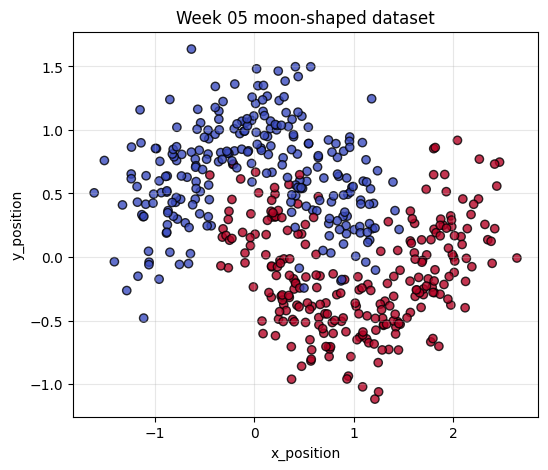

In [22]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

scatter = ax.scatter(
    points["x_position"],
    points["y_position"],
    c=points["class_label"],
    cmap="coolwarm",
    edgecolor="black",
    alpha=0.8
)

ax.set_title("Week 05 moon-shaped dataset")
ax.set_xlabel("x_position")
ax.set_ylabel("y_position")
ax.grid(True, alpha=0.3)

plt.show()


## Raw data observation

The two classes form curved moon shapes.

A single straight line may classify many points correctly, but it probably cannot cleanly separate the two curves.

In [23]:
from sklearn.model_selection import train_test_split

features = points[["x_position", "y_position"]].to_numpy()
labels = points["class_label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    features,
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=labels,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (400, 2)
X_test: (100, 2)
y_train: (400,)
y_test: (100,)


## Convert arrays to tensors

`X_train` is a matrix of input positions with shape `(400, 2)`.

`y_train` is one class label per row. We reshape it to `(400, 1)` so it matches the model output shape.

In [24]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

print("X_train_tensor:", X_train_tensor.shape, X_train_tensor.dtype)
print("y_train_tensor:", y_train_tensor.shape, y_train_tensor.dtype)
print("X_test_tensor:", X_test_tensor.shape, X_test_tensor.dtype)
print("y_test_tensor:", y_test_tensor.shape, y_test_tensor.dtype)

X_train_tensor: torch.Size([400, 2]) torch.float32
y_train_tensor: torch.Size([400, 1]) torch.float32
X_test_tensor: torch.Size([100, 2]) torch.float32
y_test_tensor: torch.Size([100, 1]) torch.float32


In [25]:
import torch.nn as nn

torch.manual_seed(RANDOM_STATE)

linear_model = nn.Linear(in_features=2, out_features=1)

for name, parameter in linear_model.named_parameters():
    print(name, parameter.shape)
    
with torch.no_grad():
    sample_logits = linear_model(X_train_tensor[:5])

print(f"sample_logits shape: {sample_logits.shape}")
sample_logits

weight torch.Size([1, 2])
bias torch.Size([1])
sample_logits shape: torch.Size([5, 1])


tensor([[ 0.3178],
        [ 0.6995],
        [-0.3307],
        [-0.4307],
        [ 0.1584]])

## Logits and sigmoid

The linear model outputs logits.

A logit is a raw score. Sigmoid turns each logit into a probability between `0` and `1`.

Positive logits become probabilities above `0.5`; negative logits become probabilities below `0.5`.

In [26]:
torch.sigmoid(sample_logits)

tensor([[0.5788],
        [0.6681],
        [0.4181],
        [0.3940],
        [0.5395]])

## Train the linear baseline

The linear model can only learn one direct recipe:

`score = weight_1 * x_position + weight_2 * y_position + bias`

Because the moons are curved, this model may improve for many epochs but still hit a shape limit.

In [29]:
loss_function = nn.BCEWithLogitsLoss()

linear_optimizer = torch.optim.SGD(linear_model.parameters(), lr=LEARNING_RATE)

linear_losses: list[float] = []

for epoch in range(2000):
    linear_model.train()
    
    logits = linear_model(X_train_tensor)
    loss = loss_function(logits, y_train_tensor)
    
    linear_optimizer.zero_grad()
    loss.backward()
    linear_optimizer.step()
    
    linear_losses.append(float(loss.item()))
    
    if epoch % 200 == 0:
        print(f"epoch {epoch}, loss {loss.item():.4f}")
        
print(f"Final linear loss: {linear_losses[-1]:.4f}")

epoch 0, loss 0.3599
epoch 200, loss 0.3538
epoch 400, loss 0.3486
epoch 600, loss 0.3440
epoch 800, loss 0.3401
epoch 1000, loss 0.3365
epoch 1200, loss 0.3334
epoch 1400, loss 0.3306
epoch 1600, loss 0.3281
epoch 1800, loss 0.3258
Final linear loss: 0.3238


In [30]:
def binary_accuracy_from_logits(logits: torch.Tensor, labels: torch.Tensor) -> float:
       probabilities = torch.sigmoid(logits)
       predictions = (probabilities >= 0.5).float()
       accuracy = (predictions == labels).float().mean()
       return float(accuracy.item())


linear_model.eval()

with torch.no_grad():
    train_logits = linear_model(X_train_tensor)
    test_logits = linear_model(X_test_tensor)

    linear_train_accuracy = binary_accuracy_from_logits(train_logits, y_train_tensor)
    linear_test_accuracy = binary_accuracy_from_logits(test_logits, y_test_tensor)
    linear_final_loss = loss_function(train_logits, y_train_tensor)

print(f"linear train accuracy: {linear_train_accuracy:.3f}")
print(f"linear test accuracy: {linear_test_accuracy:.3f}")
print(f"linear final train loss: {linear_final_loss.item():.4f}")

linear train accuracy: 0.848
linear test accuracy: 0.820
linear final train loss: 0.3238


## Linear baseline findings

The linear model reached:

- train accuracy: `0.848`
- test accuracy: `0.820`
- final train loss: `0.3238`

Because both train and test accuracy are limited, this looks more like a model-capacity limit than overfitting.

Next we need to train an MLP with one hidden layer and compare whether extra learned features help bend the decision boundary.